# Seyf Monte Carlo Yield & Portfolio Simulation

This interactive notebook prototype simulates the financial performance of Seyf's **$100,000 USD** loan-oriented yield fund.
It models interest rate fluctuations (Vasicek), USD/MXN exchange rate fluctuations (GBM), default rate fluctuations (mean-reverting OU-like process), monthly cashflows, defaults, opex, and compound reinvestment over a 12-month horizon.

**Internal Use Only**: This notebook is for planning and stress-testing purposes. It does not constitute financial advice.

## Setup and Imports
Necessary library imports for data manipulation, numerical simulation, and visualization.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Seedable PRNG (Mulberry32 & Box-Muller)
To ensure exact mathematical alignment with the TypeScript production code, we implement the Mulberry32 PRNG and Box-Muller transform in Python.

In [11]:
class SeededRandom:
    def __init__(self, seed: int):
        self.a = seed

    def next_uniform(self) -> float:
        # Mulberry32 algorithm using standard Python operators to mimic 32-bit imul
        self.a = (self.a + 0x6d2b79f5) & 0xFFFFFFFF
        t = self.a
        # Python's integer handles overflow automatically, so we bitwise AND with 0xFFFFFFFF to keep it 32-bit
        t = ((t ^ (t >> 15)) * (t | 1)) & 0xFFFFFFFF
        t = (t ^ (t + (((t ^ (t >> 7)) * (t | 61)) & 0xFFFFFFFF))) & 0xFFFFFFFF
        return ((t ^ (t >> 14)) >> 0) / 4294967296.0

    def next_normal(self) -> float:
        u = 0.0
        v = 0.0
        while u == 0.0:
            u = self.next_uniform()
        while v == 0.0:
            v = self.next_uniform()
        return np.sqrt(-2.0 * np.log(u)) * np.cos(2.0 * np.pi * v)

## 2. Simulation Engine Implementation
Below is the simulation logic. We trace individual monthly trajectories for interest rates, exchange rates, default rates, and fund balances.

In [9]:
def run_simulation(
    num_trials=10000,
    initial_capital=100000.0,
    horizon_months=12,
    utilization_rate=0.8,
    rate_mean_reversion=2.0,
    rate_long_term_mean=0.11,
    rate_volatility=0.02,
    initial_rate=0.11,
    fx_drift=0.0,
    fx_volatility=0.1,
    rate_fx_correlation=-0.3,
    initial_fx_rate=18.0,
    loan_spread=0.15,
    default_mean_reversion=1.5,
    default_long_term_mean=0.05,
    default_volatility=0.015,
    initial_default_rate=0.05,
    lgd=0.6,
    monthly_opex=500.0,
    seed=42
):
    rng = SeededRandom(seed)
    dt = 1.0 / 12.0
    sqrt_dt = np.sqrt(dt)
    rho = rate_fx_correlation

    plot_trials = min(100, num_trials)
    r_paths = np.zeros((plot_trials, horizon_months + 1))
    S_paths = np.zeros((plot_trials, horizon_months + 1))
    p_paths = np.zeros((plot_trials, horizon_months + 1))
    F_paths = np.zeros((plot_trials, horizon_months + 1))

    trial_net_profits = []
    trial_min_capitals = []

    for i in range(num_trials):
        F = initial_capital
        r = initial_rate
        S = initial_fx_rate
        p = initial_default_rate
        min_capital = initial_capital

        if i < plot_trials:
            r_paths[i, 0] = r
            S_paths[i, 0] = S
            p_paths[i, 0] = p
            F_paths[i, 0] = F

        for t in range(horizon_months):
            Z1 = rng.next_normal()
            W = rng.next_normal()
            Z2 = rho * Z1 + np.sqrt(1 - rho*rho) * W
            Z3 = rng.next_normal()

            next_S = S * np.exp((fx_drift - 0.5 * fx_volatility**2) * dt + fx_volatility * sqrt_dt * Z2)

            V = F * utilization_rate
            B = F * (1.0 - utilization_rate)

            inc_loan = V * (r + loan_spread) * dt
            inc_bond = B * ((1.0 + r * dt) * (S / next_S) - 1.0)
            loss_def = V * p * lgd * dt

            net_profit_month = inc_loan + inc_bond - loss_def - monthly_opex
            F += net_profit_month
            min_capital = min(min_capital, F)

            r = r + rate_mean_reversion * (rate_long_term_mean - r) * dt + rate_volatility * sqrt_dt * Z1
            r = max(0.0, r)

            p = p + default_mean_reversion * (default_long_term_mean - p) * dt + default_volatility * sqrt_dt * Z3
            p = min(1.0, max(0.0, p))

            S = next_S

            if i < plot_trials:
                r_paths[i, t + 1] = r
                S_paths[i, t + 1] = S
                p_paths[i, t + 1] = p
                F_paths[i, t + 1] = F

        trial_net_profits.append(F - initial_capital)
        trial_min_capitals.append(min_capital)

    return {
        "profits": np.array(trial_net_profits),
        "min_capitals": np.array(trial_min_capitals),
        "r_paths": r_paths,
        "S_paths": S_paths,
        "p_paths": p_paths,
        "F_paths": F_paths
    }

## 3. Execute Simulation
We run the simulation for 10,000 trials.

In [4]:
res = run_simulation(num_trials=10000, initial_capital=100000.0)
profits = res["profits"]
min_capitals = res["min_capitals"]

## 4. Compute Aggregate Metrics
We compute statistics, percentiles, 95% Value at Risk, and suggested capital buffer.

In [5]:
expected_profit = np.mean(profits)
std_profit = np.std(profits)
prob_loss = np.mean(profits < 0)
p5 = np.percentile(profits, 5)
p10 = np.percentile(profits, 10)
p50 = np.percentile(profits, 50)
p90 = np.percentile(profits, 90)
p95 = np.percentile(profits, 95)
var_95 = -p5
suggested_buffer = max(0.0, 100000.0 - np.percentile(min_capitals, 1))

print(f"================ SIMULATION RESULTS ================ ")
print(f"Expected Net Profit       : ${expected_profit:,.2f}")
print(f"Profit Standard Deviation  : ${std_profit:,.2f}")
print(f"Probability of Loss       : {prob_loss * 100:.2f}%")
print(f"Value at Risk (VaR 95%)   : ${var_95:,.2f}")
print(f"Suggested Capital Buffer  : ${suggested_buffer:,.2f}")
print(f"====================================================\n")

print(f"=================== PERCENTILES =================== ")
print(f"5th Percentile (Worst 5%) : ${p5:,.2f}")
print(f"10th Percentile           : ${p10:,.2f}")
print(f"50th Percentile (Median)  : ${p50:,.2f}")
print(f"90th Percentile           : ${p90:,.2f}")
print(f"95th Percentile (Best 5%)  : ${p95:,.2f}")
print(f"==================================================== ")

================ SIMULATION RESULTS ================ 
Expected Net Profit       : $16,269.69
Profit Standard Deviation  : $2,711.42
Probability of Loss       : 0.00%
Value at Risk (VaR 95%)   : $-11,810.10
Suggested Capital Buffer  : $133.65

=================== PERCENTILES =================== 
5th Percentile (Worst 5%) : $11,810.10
10th Percentile           : $12,788.33
50th Percentile (Median)  : $16,216.22
90th Percentile           : $19,781.22
95th Percentile (Best 5%)  : $20,772.28


## 5. Visualizations
We plot the distribution of net profit and sample simulation paths.

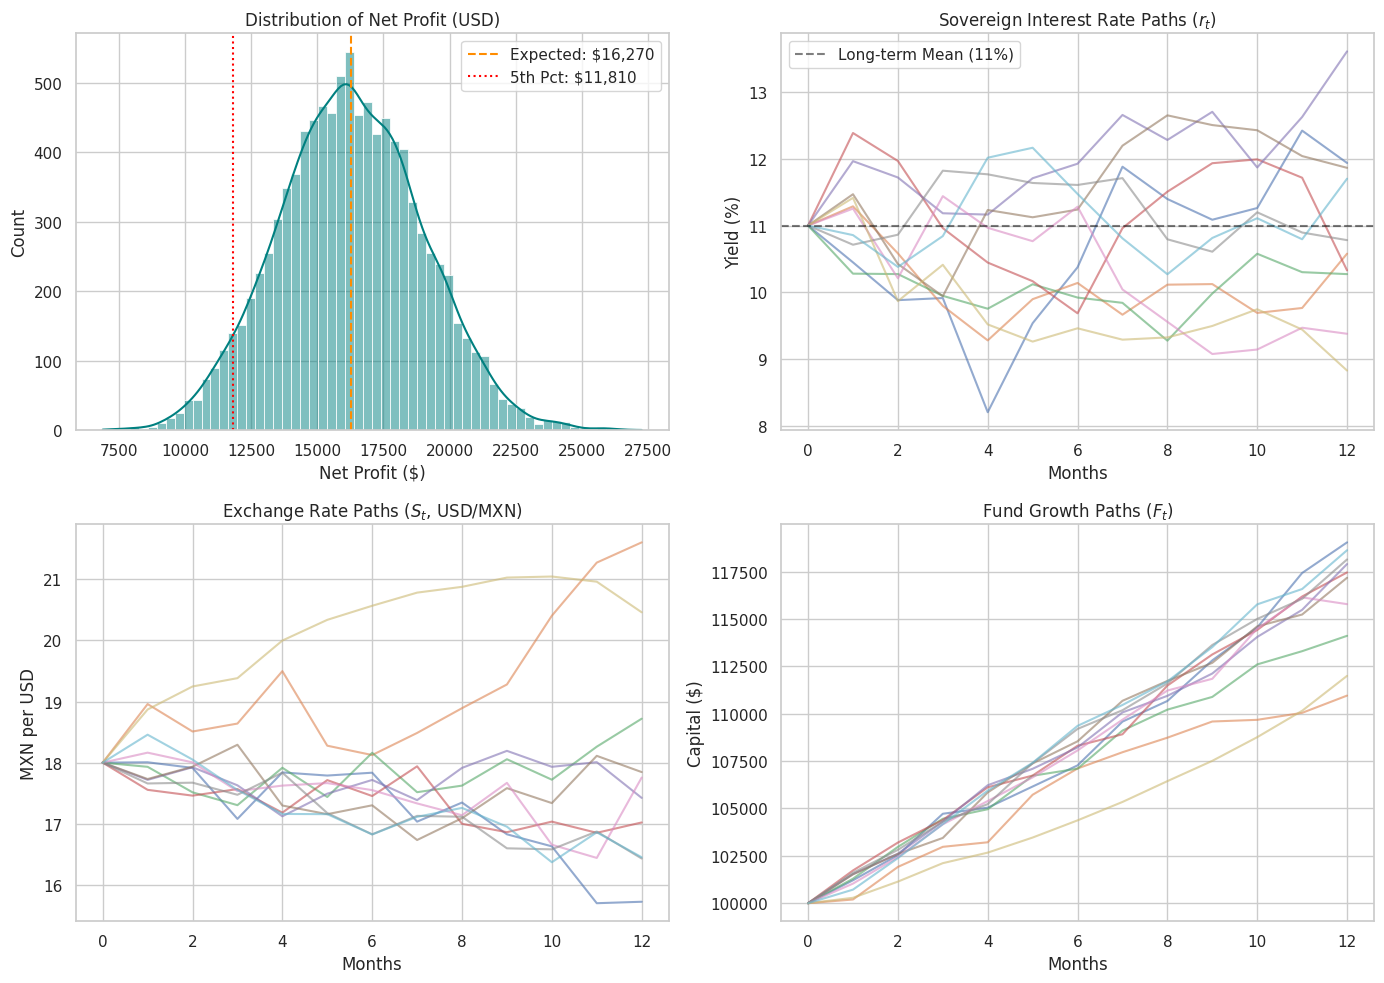

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Net Profit Distribution
sns.histplot(profits, kde=True, ax=axes[0, 0], color="teal")
axes[0, 0].axvline(expected_profit, color="darkorange", linestyle="--", label=f"Expected: ${expected_profit:,.0f}")
axes[0, 0].axvline(p5, color="red", linestyle=":", label=f"5th Pct: ${p5:,.0f}")
axes[0, 0].set_title("Distribution of Net Profit (USD)")
axes[0, 0].set_xlabel("Net Profit ($)")
axes[0, 0].legend()

# B. Sovereign Yield (CETES) paths
for i in range(10):
    axes[0, 1].plot(res["r_paths"][i] * 100, alpha=0.6)
axes[0, 1].axhline(11.0, color="black", linestyle="--", alpha=0.5, label="Long-term Mean (11%)")
axes[0, 1].set_title("Sovereign Interest Rate Paths ($r_t$)")
axes[0, 1].set_xlabel("Months")
axes[0, 1].set_ylabel("Yield (%)")
axes[0, 1].legend()

# C. Exchange Rate (USD/MXN) paths
for i in range(10):
    axes[1, 0].plot(res["S_paths"][i], alpha=0.6)
axes[1, 0].set_title("Exchange Rate Paths ($S_t$, USD/MXN)")
axes[1, 0].set_xlabel("Months")
axes[1, 0].set_ylabel("MXN per USD")

# D. Fund Capital paths
for i in range(10):
    axes[1, 1].plot(res["F_paths"][i], alpha=0.6)
axes[1, 1].set_title("Fund Growth Paths ($F_t$)")
axes[1, 1].set_xlabel("Months")
axes[1, 1].set_ylabel("Capital ($)")

plt.tight_layout()
plt.show()